# Calibration

Notebooks 03 to 05 judge the models on ranking. A PD model also has to get the level right: when it says 2%, about 2% of those firms should default, because pricing, provisions and capital all use the number itself. The three models are rebuilt here exactly as in notebooks 03, 04 and 05 (LightGBM with the same settings and the median tree count from the same year-based CV), and scored on every split.

In [12]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

from src.data import load_data, split_by_year
from src.features import add_ratios
from src.config import FEATURES, GBM_PARAMS, RISK_TREND, ROOT, SEED
from src.metrics import reliability, evaluate, _firm_rows, _resample
from src.gbm import cv_lgb, fit_lgb
from src.scorecard import WOEBinner
from src.benchmark import zpp_components, fit_caps, altman_zpp, ZScoreToPD
from src.calibration import LogitRecalibrator, plot_reliability

In [13]:
train, val, test = (add_ratios(d) for d in split_by_year(load_data()))
splits = {"train": train, "val": val, "test": test}

In [14]:
# Z'' benchmark (notebook 03)
caps = fit_caps(zpp_components(train))
z_map = ZScoreToPD().fit(altman_zpp(train, caps), train["default"])

# WOE scorecard (notebook 04)
binner = WOEBinner(RISK_TREND).fit(train, train["default"])
scorecard = LogisticRegression(max_iter=1000, C=np.inf).fit(binner.transform(train), train["default"])

# LightGBM (notebook 05)
n_trees = int(cv_lgb(train, FEATURES)["trees"].median())
model = fit_lgb(train, None, FEATURES, {**GBM_PARAMS, "n_estimators": n_trees})
n_trees

279

## Calibration-in-the-large

Calibration-in-the-large compares the mean PD with the observed default rate:

In [15]:
split_pd = {
    name: {
        "z''": z_map.predict_proba(altman_zpp(d, caps)),
        "scorecard": scorecard.predict_proba(binner.transform(d))[:, 1],
        "lightgbm": model.predict_proba(d[FEATURES])[:, 1],
    }
    for name, d in splits.items()
}

rows = []
for split, d in splits.items():
    for name, p in split_pd[split].items():
        observed = d["default"].mean()
        rows.append({"model": name, "split": split, "mean_pd": p.mean(), "observed": observed, "ratio": p.mean() / observed})
pd.DataFrame(rows).set_index(["model", "split"]).round(4)

,,mean_pd,observed,ratio
model,split,,,
z'',train,0.0072,0.0072,1.0000
scorecard,train,0.0072,0.0072,0.9997
lightgbm,train,0.0072,0.0072,1.0000
z'',val,0.0076,0.0083,0.9167
scorecard,val,0.0065,0.0083,0.7781
lightgbm,val,0.0057,0.0083,0.6891
z'',test,0.0076,0.0097,0.7812
scorecard,test,0.0069,0.0097,0.7119
lightgbm,test,0.0070,0.0097,0.7175


## Reliability

Reliability on test. Firm-years are sorted by predicted PD and cut into 10 groups holding equal numbers of defaults (about 12 each), so every point is about equally precise: the safe end becomes a few large groups and the risky end several small ones. Each group's mean PD is plotted against its observed default rate, with a 95% Wilson interval for the true rate. Points on the diagonal are well calibrated; points above it are under-predicted. The group edges depend on the outcomes, which is fine for a diagnostic but means groups do not line up across models.

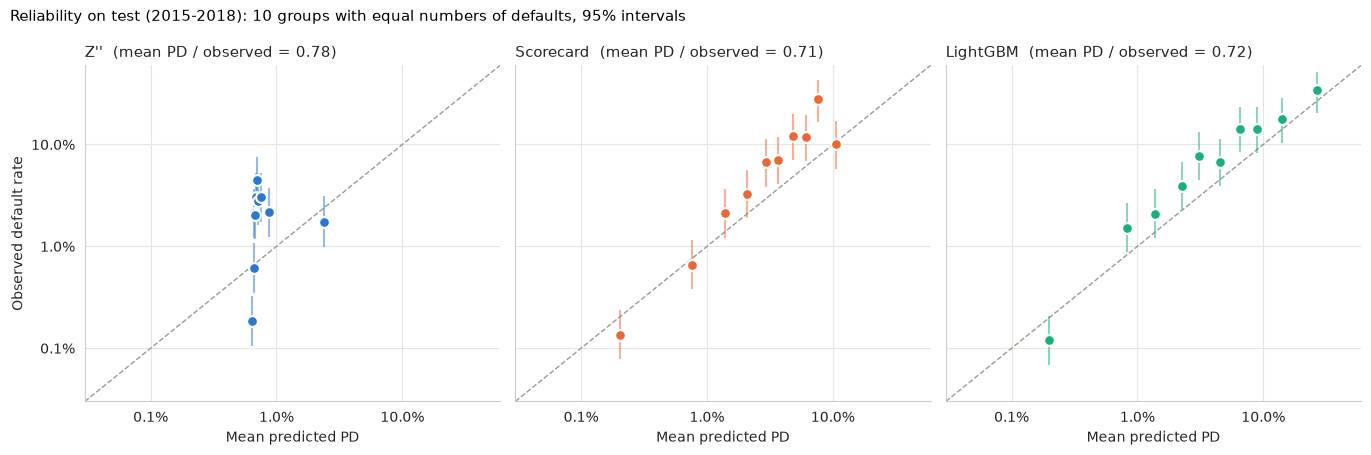

In [16]:
NAMES = {"z''": "Z''", "scorecard": "Scorecard", "lightgbm": "LightGBM"}

# the groups behind the figure, shown in the next cell
rel = {NAMES[k]: reliability(test["default"], p, n_bins=10, strategy="defaults") for k, p in split_pd["test"].items()}

plot_reliability(
    {NAMES[k]: p for k, p in split_pd["test"].items()},
    test["default"],
    "Reliability on test (2015-2018): 10 groups with equal numbers of defaults, 95% intervals",
    ROOT / "figures" / "reliability.png",
);

In [17]:
# the figure's groups, then equal-sized groups (tenths of the book), which the shortfall figures below come from
display(pd.concat({name: r[["n", "defaults", "mean_pred", "observed"]] for name, r in rel.items()}, axis=1).round(4))
deciles = {NAMES[k]: reliability(test["default"], p, n_bins=10) for k, p in split_pd["test"].items()}
pd.concat({name: r[["defaults", "mean_pred", "observed"]] for name, r in deciles.items()}, axis=1).round(4)

Z''                             Scorecard                              \
        n defaults mean_pred observed         n defaults mean_pred observed   
bin                                                                           
0    6489       12    0.0064   0.0018      8834       12    0.0020   0.0014   
1    1958       12    0.0066   0.0061      1809       12    0.0076   0.0066   
2     570       12    0.0067   0.0211       568       12    0.0138   0.0211   
3     589       12    0.0068   0.0204       366       12    0.0208   0.0328   
4     393       12    0.0069   0.0305       180       12    0.0295   0.0667   
5     270       12    0.0070   0.0444       171       12    0.0366   0.0702   
6     428       12    0.0071   0.0280       100       12    0.0487   0.1200   
7     396       12    0.0075   0.0303       102       12    0.0608   0.1176   
8     557       12    0.0087   0.0215        43       12    0.0770   0.2791   
9     632       11    0.0237   0.0174       109       11    0.1059   0.1009   

    LightGBM                              
           n defaults mean_pred observed  
bin                                       
0      10015       12    0.0020   0.0012  
1        790       12    0.0082   0.0152  
2        571       12    0.0139   0.0210  
3        305       12    0.0227   0.0393  
4        154       12    0.0311   0.0779  
5        178       12    0.0451   0.0674  
6         84       12    0.0650   0.1429  
7         85       12    0.0895   0.1412  
8         68       12    0.1409   0.1765  
9         32       11    0.2670   0.3438

Z''                    Scorecard                    LightGBM  \
    defaults mean_pred observed  defaults mean_pred observed defaults   
bin                                                                     
0          2    0.0062   0.0016         0    0.0006   0.0000        1   
1          1    0.0064   0.0008         0    0.0009   0.0000        0   
2          1    0.0065   0.0008         1    0.0014   0.0008        0   
3          4    0.0065   0.0033         2    0.0018   0.0016        0   
4          2    0.0066   0.0016         0    0.0023   0.0000        0   
5          4    0.0066   0.0033         3    0.0029   0.0024        4   
6         13    0.0066   0.0106         3    0.0040   0.0024        3   
7         26    0.0068   0.0212         9    0.0059   0.0073        2   
8         40    0.0072   0.0326        12    0.0105   0.0098       20   
9         26    0.0163   0.0212        89    0.0388   0.0724       89   

                        
    mean_pred observed  
bin                     
0      0.0005   0.0008  
1      0.0008   0.0000  
2      0.0011   0.0000  
3      0.0013   0.0000  
4      0.0017   0.0000  
5      0.0022   0.0033  
6      0.0031   0.0024  
7      0.0047   0.0016  
8      0.0086   0.0163  
9      0.0455   0.0724

On train every model matches the default rate, as a model fitted there must. Out of time all three under-predict: test mean PD is 78% of the observed rate for Z'', 71% for the scorecard and 72% for LightGBM.

The reliability curves show where. For the scorecard and LightGBM the points rise in step with the diagonal, so the ranking holds, and the safest group (72% and 82% of the book) is within its interval. Above a predicted PD of about 1%, though, 8 of the 9 remaining groups sit above the line, with observed rates 1.5 to 2.5 times the prediction. Each group has only 12 defaults, so a single point can miss by chance, but together those groups expect 67 and 65 defaults against 107 observed. On a log scale a factor of two is a third of a gridline, so the gap looks smaller than it is.

The equal-sized groups in the second table say the same: in the riskiest tenth the scorecard and LightGBM predict 3.9% and 4.6% against 7.2% observed. That tenth holds 89 of the 119 test defaults and the whole shortfall: the scorecard expects 48 defaults there and 37 in the other nine tenths, against 89 and 30 observed (LightGBM: 56 and 29). Z'' is a different failure: its PDs barely move (0.6% to 2.4% across the groups), so it is roughly right on average and wrong almost everywhere.

### Fix and Calibrate

In [18]:
ref = train["default"].mean()
recal_pd, rows = {}, []

for name in ["scorecard", "lightgbm"]:
    p_val, y_val = split_pd["val"][name], val["default"]
    p_test, y_test = split_pd["test"][name], test["default"]
    
    rc = LogitRecalibrator().fit(p_val, y_val)
    p_new = rc.predict_proba(p_test)
    recal_pd[name] = p_new
    
    before, after = evaluate(y_test, p_test, ref), evaluate(y_test, p_new, ref)
    
    rows.append({
        "model": name, "a": rc.a_, "b": rc.b_,
        "pd/obs before": before["mean_pred"] / before["base_rate"],
        "pd/obs after": after["mean_pred"] / after["base_rate"],
        "brier before": before["brier"], "brier after": after["brier"],
        "auc before": before["roc_auc"], "auc after": after["roc_auc"],
        "ks before": before["ks"], "ks after": after["ks"],
    })

pd.DataFrame(rows).set_index("model").round(4)


,a,b,pd/obs before,pd/obs after,brier before,brier after,auc before,auc after,ks before,ks after
model,,,,,,,,,,
scorecard,1.1784,1.2324,0.7119,0.9228,0.0092,0.0091,0.9063,0.9063,0.6767,0.6767
lightgbm,1.4465,1.2684,0.7175,1.1111,0.0088,0.0088,0.9248,0.9248,0.7329,0.7329


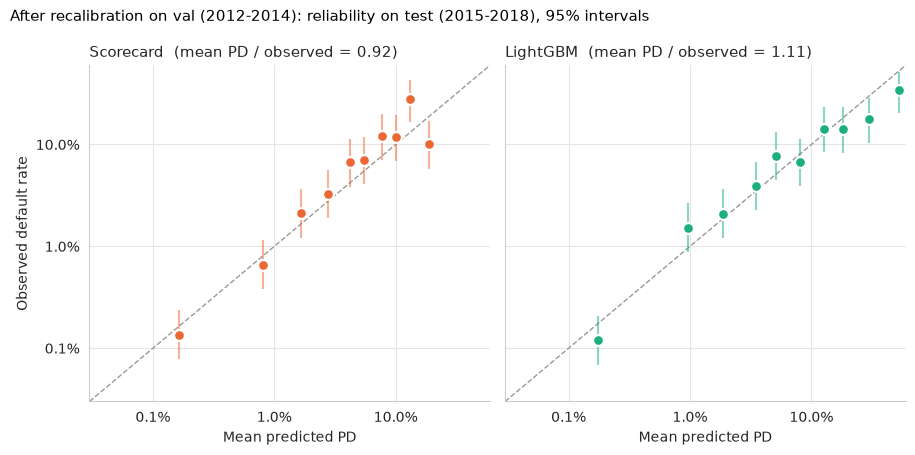

In [19]:
plot_reliability(
    {NAMES[k]: p for k, p in recal_pd.items()},
    test["default"],
    "After recalibration on val (2012-2014): reliability on test (2015-2018), 95% intervals",
    ROOT / "figures" / "reliability_recalibrated.png",
);

To explain the overshoot on LightGBM (to 1.11):

In [21]:
rng  = np.random.default_rng(SEED)

firm_rows = _firm_rows(val["company_name"])
y_val, y_test = val["default"].to_numpy(), test["default"].to_numpy()

In [ ]:
rows = []
for name in ["scorecard", "lightgbm"]:
    p_val, p_test = split_pd["val"][name], split_pd["test"][name]

    a_s, b_s, ratios = [], [], []
    for _ in range(500):
        i = _resample(rng, len(y_val), firm_rows)
        if y_val[i].sum() == 0:
            continue
        rc = LogitRecalibrator().fit(p_val[i], y_val[i])
        a_s.append(rc.a_)
        b_s.append(rc.b_)
        ratios.append(rc.predict_proba(p_test).mean() / y_test.mean())
    


In [28]:
print("95% interval for the slope: ", np.quantile(b_s, [0.025, 0.975]))
print("95% interval for the calibration ratio: ",np.quantile(ratios, [0.025, 0.975]))

95% interval for the slope:  [1.10933502 1.40695561]
95% interval for the calibration ratio:  [0.89800222 1.32285404]
